# Amna Kauser 

# Task: 4 Predicting Insurance Claim Amounts

In [1]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn 
import sklearn as sk
from sklearn.preprocessing import LabelEncoder


In [4]:
#loading dataset
insurance=pd.read_csv('C:/Users/User/Downloads/archive (6)/insurance.csv')

In [5]:
#checking the dataset 
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#checking the no of rows and columns
insurance.shape

(1338, 7)

# Training a Linear Regression model to predict charges.

In [7]:
#Train a Linear Regression Model to Predict Charges
 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
 
# Encode categorical columns into numbers
le = LabelEncoder()
insurance["sex"]    = le.fit_transform(insurance["sex"])
insurance["smoker"] = le.fit_transform(insurance["smoker"])
insurance["region"] = le.fit_transform(insurance["region"])
 
# Features and Target
X = insurance[["age", "sex", "bmi", "children", "smoker", "region"]]
y = insurance["charges"]
 
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
 
print("Model trained successfully!")
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Model trained successfully!
Training samples : 1070
Testing  samples : 268


# Visualizing how BMI, age, and smoking status impact insurance charges.

In [11]:
#loading again original dataset
insurance=pd.read_csv('C:/Users/User/Downloads/archive (6)/insurance.csv')

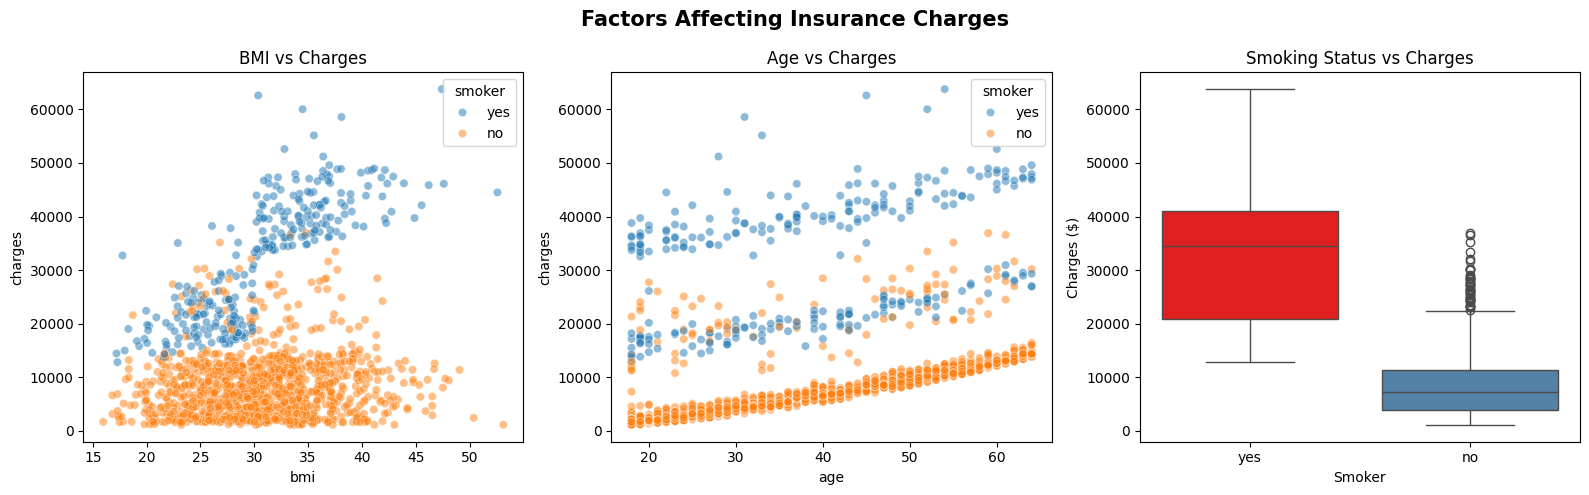

In [15]:
#visulizing
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Factors Affecting Insurance Charges", fontsize=15, fontweight="bold")

# Plot 1 — BMI vs Charges
sn.scatterplot(data=insurance, x="bmi", y="charges", hue="smoker", ax=axes[0], alpha=0.5)
axes[0].set_title("BMI vs Charges")

# Plot 2 — Age vs Charges
sn.scatterplot(data=insurance, x="age", y="charges", hue="smoker", ax=axes[1], alpha=0.5)
axes[1].set_title("Age vs Charges")

# Plot 3 — Smoking Status vs Charges
sn.boxplot(data=insurance, x="smoker", y="charges",
            hue="smoker", palette={"yes": "red", "no": "steelblue"},
            legend=False, ax=axes[2])
axes[2].set_title("Smoking Status vs Charges")
axes[2].set_xlabel("Smoker")
axes[2].set_ylabel("Charges ($)")

plt.tight_layout()
plt.savefig("visualizations.png", dpi=150, bbox_inches="tight")
plt.show()

BMI & Age plots — Smokers (blue) are charged significantly more than non-smokers (orange) across all BMI and age groups,
and charges clearly increase as age goes up especially for smokers.

Smoking Status boxplot — Smokers pay around $20,000-$40,000 on average while non-smokers pay only around $5,000-$10,000, 
confirming that smoking is the biggest factor driving insurance charges.

The model predicts that smoking status is the most powerful factor in determining insurance charges — a smoker will always pay 3-4 times more than a non-smoker, regardless of their age or BMI.

# Evaluating model performance using MAE and RMSE.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

#loading dataset
insurance=pd.read_csv('C:/Users/User/Downloads/archive (6)/insurance.csv')

# Encode categorical columns into numbers
le = LabelEncoder()
insurance["sex"]    = le.fit_transform(insurance["sex"])
insurance["smoker"] = le.fit_transform(insurance["smoker"])
insurance["region"] = le.fit_transform(insurance["region"])
 
# Features and Target
X = insurance[["age", "sex", "bmi", "children", "smoker", "region"]]
y = insurance["charges"]
 
# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
 
# Predict
y_pred = model.predict(X_test)
 
# Evaluate
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)
 
print("Model Evaluation")
print(f"MAE   (Mean Absolute Error) : ${mae:,.2f}")
print(f"RMSE  (Root Mean Sq. Error) : ${rmse:,.2f}")
print(f"R²    (Accuracy Score)      : {r2:.4f}")

print(f"\nInterpretation:")
print(f"  → On average, predictions are off by ${mae:,.0f}")
print(f"  → The model explains {r2*100:.1f}% of the variation in charges")

Model Evaluation
MAE   (Mean Absolute Error) : $4,186.51
RMSE  (Root Mean Sq. Error) : $5,799.59
R²    (Accuracy Score)      : 0.7833

Interpretation:
  → On average, predictions are off by $4,187
  → The model explains 78.3% of the variation in charges
